# Feature Engineering

Encode categorical features, derive time-based signals, build interactions, and save processed datasets.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

test["flood_risk_score"] = np.nan
combined = pd.concat([train, test], axis=0).reset_index(drop=True)

print("Train:", train.shape)
print("Test: ", test.shape)
print("Combined:", combined.shape)

Train: (20886, 47)
Test:  (5300, 47)
Combined: (26186, 47)


In [30]:
drop_cols = ["is_synthetic", "place_name"]
existing_drop_cols = [col for col in drop_cols if col in combined.columns]
combined = combined.drop(columns=existing_drop_cols)
print("Dropped:", existing_drop_cols)

Dropped: ['is_synthetic', 'place_name']


In [31]:
combined["generation_date"] = pd.to_datetime(combined["generation_date"], errors="coerce")
combined["gen_month"] = combined["generation_date"].dt.month
combined["gen_year"] = combined["generation_date"].dt.year
combined["gen_quarter"] = combined["generation_date"].dt.quarter

combined["is_monsoon_season"] = combined["gen_month"].isin(
    [5, 6, 7, 8, 9, 10, 11]
).astype(int)

combined = combined.drop(columns=["generation_date"])
print("Date features extracted")

Date features extracted


In [32]:
binary_map = {
    "flood_occurrence_current_event": {"Yes": 1, "No": 0},
    "is_good_to_live": {"Yes": 1, "No": 0},
    "water_presence_flag": {"Likely": 1, "Unlikely": 0},
    "urban_rural": {"Urban": 1, "Rural": 0},
}

for col, mapping in binary_map.items():
    if col in combined.columns:
        combined[col] = combined[col].map(mapping)

print("Binary columns encoded")

Binary columns encoded


In [33]:
road_order = {
    "Good (paved)": 3,
    "Fair": 2,
    "Poor (unpaved)": 1,
    "No road access": 0,
}

electricity_order = {
    "Grid": 2,
    "Mixed": 1,
    "Off-grid (solar)": 0,
}

water_supply_order = {
    "Municipal": 4,
    "Tube-well": 3,
    "Well": 2,
    "Surface water": 1,
    "Rainwater harvesting": 0,
}

if "road_quality" in combined.columns:
    combined["road_quality"] = combined["road_quality"].map(road_order)
if "electricity" in combined.columns:
    combined["electricity"] = combined["electricity"].map(electricity_order)
if "water_supply" in combined.columns:
    combined["water_supply"] = combined["water_supply"].map(water_supply_order)

print("Ordinal columns encoded")

Ordinal columns encoded


In [34]:
if "reason_not_good_to_live" in combined.columns:
    combined["reason_flood_risk"] = combined["reason_not_good_to_live"].str.contains(
        "High flood risk", na=False
    ).astype(int)
    combined["reason_poor_infra"] = combined["reason_not_good_to_live"].str.contains(
        "Poor infrastructure", na=False
    ).astype(int)
    combined["reason_no_road"] = combined["reason_not_good_to_live"].str.contains(
        "No road access", na=False
    ).astype(int)

    combined["reason_count"] = (
        combined["reason_flood_risk"]
        + combined["reason_poor_infra"]
        + combined["reason_no_road"]
    )

    combined = combined.drop(columns=["reason_not_good_to_live"])

print("reason_not_good_to_live parsed into flags")

reason_not_good_to_live parsed into flags


In [35]:
if "district" in train.columns:
    district_mean = train.groupby("district")["flood_risk_score"].mean()
    district_std = train.groupby("district")["flood_risk_score"].std()
    district_count = train.groupby("district")["flood_risk_score"].count()

    combined["district_risk_mean"] = combined["district"].map(district_mean)
    combined["district_risk_std"] = combined["district"].map(district_std)
    combined["district_risk_count"] = combined["district"].map(district_count)

    combined["district_encoded"] = LabelEncoder().fit_transform(
        combined["district"].fillna("Unknown")
    )

    combined = combined.drop(columns=["district"])

print("district encoded")

district encoded


In [36]:
for col in ["landcover", "soil_type"]:
    if col in train.columns:
        col_mean = train.groupby(col)["flood_risk_score"].mean()
        combined[f"{col}_risk_mean"] = combined[col].map(col_mean)
        combined[f"{col}_encoded"] = LabelEncoder().fit_transform(
            combined[col].fillna("Unknown")
        )
        combined = combined.drop(columns=[col])

print("landcover and soil_type encoded")

landcover and soil_type encoded


In [37]:
combined["rainfall_drainage_interaction"] = (
    combined["rainfall_7d_mm_log1p"]
    * (1 - combined["drainage_index_yeojohnson"].fillna(0))
)

combined["river_rainfall_risk"] = (
    combined["rainfall_7d_mm_log1p"]
    / (combined["distance_to_river_m_log1p"] + 1)
)

combined["elevation_river_risk"] = (
    1 / (combined["elevation_m"].fillna(combined["elevation_m"].median()) + 1)
    * 1
    / (
        combined["distance_to_river_m"].fillna(
            combined["distance_to_river_m"].median()
        )
        + 1
    )
)

combined["water_inundation_score"] = (
    combined["water_presence_flag"].fillna(0)
    * np.log1p(combined["inundation_area_sqm"])
)

combined["infra_gap"] = (
    combined["flood_occurrence_current_event"].fillna(0)
    * (
        1
        - combined["infrastructure_score"].fillna(
            combined["infrastructure_score"].median()
        )
        / 100
    )
)

print("Interaction features created")

Interaction features created


In [38]:
num_cols = combined.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c != "flood_risk_score"]

for col in num_cols:
    median_val = combined[col].median()
    combined[col] = combined[col].fillna(median_val)

print("Missing values filled")
print("Remaining nulls:", combined.isnull().sum().sum())

Missing values filled
Remaining nulls: 5300


In [39]:
import os

os.makedirs("../data/processed", exist_ok=True)

train_processed = combined[combined["flood_risk_score"].notna()].copy()
test_processed = combined[combined["flood_risk_score"].isna()].copy()
test_processed = test_processed.drop(columns=["flood_risk_score"])

train_processed.to_csv("../data/processed/train_processed.csv", index=False)
test_processed.to_csv("../data/processed/test_processed.csv", index=False)

print("Train processed shape:", train_processed.shape)
print("Test processed shape: ", test_processed.shape)
print("Saved to data/processed/")

Train processed shape: (20886, 61)
Test processed shape:  (5300, 60)
Saved to data/processed/


In [40]:
new_features = [
    "rainfall_drainage_interaction",
    "river_rainfall_risk",
    "elevation_river_risk",
    "water_inundation_score",
    "infra_gap",
    "reason_flood_risk",
    "reason_count",
    "district_risk_mean",
    "is_monsoon_season",
]

available_features = [f for f in new_features if f in train_processed.columns]

new_corr = (
    train_processed[available_features + ["flood_risk_score"]]
    .corr()["flood_risk_score"]
    .drop("flood_risk_score")
    .sort_values(ascending=False)
)

print("New feature correlations:")
print(new_corr.round(4))

New feature correlations:
district_risk_mean               0.1315
is_monsoon_season                0.0029
elevation_river_risk             0.0021
rainfall_drainage_interaction   -0.0058
water_inundation_score          -0.0414
reason_count                    -0.0575
infra_gap                       -0.0630
reason_flood_risk               -0.0801
river_rainfall_risk             -0.0922
Name: flood_risk_score, dtype: float64


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

train_processed = pd.read_csv('../data/processed/train_processed.csv')

drop_cols = ['record_id', 'flood_risk_score']
X = train_processed.drop(columns=drop_cols)
y = train_processed['flood_risk_score']

# Quick dirty RF — not tuned, just for importance
rf = RandomForestRegressor(n_estimators=100, max_depth=6, 
                           random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(20))
importance_df.to_csv('../results/rf_feature_importance.csv', index=False)

                          feature  importance
46             district_risk_mean    0.214380
55            river_rainfall_risk    0.163341
21            inundation_area_sqm    0.066978
35        terrain_roughness_index    0.032557
37          extreme_weather_index    0.030819
0                        latitude    0.026889
34                 seasonal_index    0.025786
17           infrastructure_score    0.024436
56           elevation_river_risk    0.024309
42              reason_flood_risk    0.021399
36     socioeconomic_status_index    0.020574
58                      infra_gap    0.019518
54  rainfall_drainage_interaction    0.017957
26      monthly_rainfall_mm_log1p    0.016507
57         water_inundation_score    0.015632
7      population_density_per_km2    0.015289
1                       longitude    0.014510
14                           ndwi    0.013416
3             distance_to_river_m    0.013386
23      distance_to_river_m_log1p    0.012127


In [42]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

scores_rmse = cross_val_score(rf, X, y, cv=5, 
                               scoring='neg_root_mean_squared_error')
scores_r2   = cross_val_score(rf, X, y, cv=5, scoring='r2')

print(f"CV RMSE : {-scores_rmse.mean():.4f} ± {scores_rmse.std():.4f}")
print(f"CV R²   : {scores_r2.mean():.4f} ± {scores_r2.std():.4f}")

CV RMSE : 0.2349 ± 0.0026
CV R²   : 0.0314 ± 0.0021


In [43]:
test_processed = pd.read_csv('../data/processed/test_processed.csv')
X_test = test_processed.drop(columns=['record_id'])

print("Train features:", X.shape[1])
print("Test features: ", X_test.shape[1])
print("Match:", X.shape[1] == X_test.shape[1])

# Check columns align
missing_in_test  = set(X.columns) - set(X_test.columns)
extra_in_test    = set(X_test.columns) - set(X.columns)
print("Missing in test:", missing_in_test)
print("Extra in test:  ", extra_in_test)

Train features: 59
Test features:  59
Match: True
Missing in test: set()
Extra in test:   set()


                     inundation_area_sqm  flood_risk_score
inundation_area_sqm             1.000000         -0.069661
flood_risk_score               -0.069661          1.000000


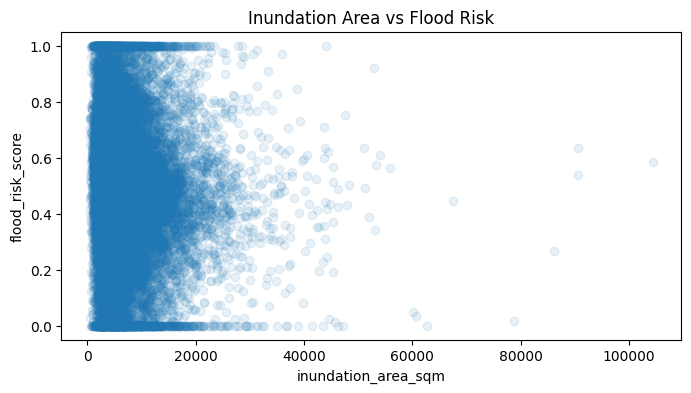

count     20886.000000
mean       7227.163650
std        5645.268756
min         396.000000
25%        3598.000000
50%        5721.500000
75%        9127.750000
max      104489.000000
Name: inundation_area_sqm, dtype: float64


In [44]:
# This is suspicious — inundation area logically derives FROM flood risk
# Check if it's too correlated
print(train[['inundation_area_sqm','flood_risk_score']].corr())

# Plot it
plt.figure(figsize=(8,4))
plt.scatter(train['inundation_area_sqm'], 
            train['flood_risk_score'], alpha=0.1)
plt.xlabel('inundation_area_sqm')
plt.ylabel('flood_risk_score')
plt.title('Inundation Area vs Flood Risk')
plt.show()

# Check value ranges
print(train['inundation_area_sqm'].describe())

In [45]:
# Target encoding can cause leakage if not done carefully
# Verify train-only encoding was used

# Check test district coverage
train_districts = set(train['district'].dropna().unique())
test_districts  = set(test['district'].dropna().unique())

print("Districts in train only:", train_districts - test_districts)
print("Districts in test only: ", test_districts - train_districts)
print("Districts in both:      ", len(train_districts & test_districts))

Districts in train only: set()
Districts in test only:  set()
Districts in both:       25
